## 2. Imports y configuración

In [8]:
import os
import cv2
import numpy as np
from PIL import Image
from pathlib import Path
from tqdm import tqdm
import shutil

# ─────────────────────────────────────────────
# CONFIGURACIÓN — ajusta estos parámetros
# ─────────────────────────────────────────────

INPUT_DIR  = "entrenamiento"           # Carpeta con las imágenes originales
OUTPUT_DIR = "entrenamiento_normalizado"  # Carpeta de salida

# Tamaño objetivo para YOLO (debe ser múltiplo de 32)
# Opciones comunes: 416, 640, 1280
TARGET_SIZE = 640  

# Extensiones de imagen aceptadas
VALID_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".tiff", ".webp"}

# Formato de salida
OUTPUT_FORMAT = ".jpg"   # '.jpg' o '.png'
JPEG_QUALITY  = 95       # Solo aplica si OUTPUT_FORMAT = '.jpg'

print(f"Entrada : {INPUT_DIR}")
print(f"Salida  : {OUTPUT_DIR}")
print(f"Tamaño  : {TARGET_SIZE}x{TARGET_SIZE}")
print(f"Formato : {OUTPUT_FORMAT}")

Entrada : entrenamiento
Salida  : entrenamiento_normalizado
Tamaño  : 640x640
Formato : .jpg


## 3. Exploración de las imágenes originales

In [ ]:
input_path = Path(INPUT_DIR)

if not input_path.exists():
    raise FileNotFoundError(f" La carpeta '{INPUT_DIR}' no existe. Verifica la ruta.")

image_files = sorted([
    f for f in input_path.iterdir()
    if f.is_file() and f.suffix.lower() in VALID_EXTENSIONS
])

print(f"✅ Imágenes encontradas: {len(image_files)}")

# Mostrar resumen de resoluciones originales
sizes = {}
for img_path in tqdm(image_files, desc="Analizando imágenes"):
    try:
        with Image.open(img_path) as img:
            w, h = img.size
            key = f"{w}x{h}"
            sizes[key] = sizes.get(key, 0) + 1
    except Exception as e:
        print(f"  No se pudo leer: {img_path.name} → {e}")

print("\n Resoluciones encontradas:")
for res, count in sorted(sizes.items(), key=lambda x: -x[1]):
    print(f"   {res} → {count} imagen(es)")

✅ Imágenes encontradas: 120


Analizando imágenes: 100%|██████████| 120/120 [00:00<00:00, 5590.79it/s]


📐 Resoluciones encontradas:
   676x465 → 1 imagen(es)
   481x804 → 1 imagen(es)
   1204x568 → 1 imagen(es)
   903x560 → 1 imagen(es)
   561x519 → 1 imagen(es)
   856x472 → 1 imagen(es)
   727x484 → 1 imagen(es)
   940x463 → 1 imagen(es)
   575x463 → 1 imagen(es)
   308x359 → 1 imagen(es)
   277x500 → 1 imagen(es)
   377x616 → 1 imagen(es)
   408x507 → 1 imagen(es)
   359x416 → 1 imagen(es)
   384x367 → 1 imagen(es)
   940x652 → 1 imagen(es)
   799x434 → 1 imagen(es)
   1179x561 → 1 imagen(es)
   579x551 → 1 imagen(es)
   1110x616 → 1 imagen(es)
   1069x613 → 1 imagen(es)
   1152x592 → 1 imagen(es)
   1066x801 → 1 imagen(es)
   1059x607 → 1 imagen(es)
   1016x700 → 1 imagen(es)
   853x580 → 1 imagen(es)
   804x669 → 1 imagen(es)
   970x689 → 1 imagen(es)
   995x638 → 1 imagen(es)
   757x634 → 1 imagen(es)
   1291x781 → 1 imagen(es)
   961x748 → 1 imagen(es)
   653x459 → 1 imagen(es)
   888x552 → 1 imagen(es)
   936x816 → 1 imagen(es)
   897x410 → 1 imagen(es)
   1052x514 → 1 imagen(es)

## 4. Función de normalización

Usa **letterbox** (padding con gris) para redimensionar sin deformar los objetos — técnica estándar en YOLO.

In [10]:
def letterbox_resize(img_bgr: np.ndarray, target_size: int = 640, pad_color: int = 114) -> np.ndarray:
    """
    Redimensiona la imagen al tamaño target_size x target_size manteniendo
    el aspect ratio original con padding (letterbox).
    
    - No deforma objetos.
    - Rellena con gris neutro (valor 114, estándar en YOLOv5/v8).
    """
    h, w = img_bgr.shape[:2]
    scale = target_size / max(h, w)
    new_w, new_h = int(w * scale), int(h * scale)

    # Redimensionar
    resized = cv2.resize(img_bgr, (new_w, new_h), interpolation=cv2.INTER_LINEAR)

    # Crear lienzo con padding
    canvas = np.full((target_size, target_size, 3), pad_color, dtype=np.uint8)

    # Centrar la imagen
    pad_top  = (target_size - new_h) // 2
    pad_left = (target_size - new_w) // 2
    canvas[pad_top:pad_top + new_h, pad_left:pad_left + new_w] = resized

    return canvas


def normalize_image(img_bgr: np.ndarray) -> np.ndarray:
    """
    Pasos de normalización visual:
      1. Corrección CLAHE en canal L (mejora contraste local sin saturar)
      2. Conversión de vuelta a BGR
    
    No normaliza a [0,1] porque las imágenes se guardan como uint8.
    YOLO hace esa normalización internamente al cargar.
    """
    # CLAHE sobre canal de luminancia
    lab   = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l_eq  = clahe.apply(l)
    lab_eq = cv2.merge((l_eq, a, b))
    result = cv2.cvtColor(lab_eq, cv2.COLOR_LAB2BGR)
    return result


print("✅ Funciones de normalización definidas.")

✅ Funciones de normalización definidas.


## 5. Procesamiento y guardado

In [11]:
output_path = Path(OUTPUT_DIR)
output_path.mkdir(parents=True, exist_ok=True)

errors = []
processed = 0

for idx, img_file in enumerate(tqdm(image_files, desc="Procesando"), start=1):
    try:
        # Leer imagen
        img = cv2.imread(str(img_file))
        if img is None:
            raise ValueError("cv2.imread retornó None")

        # 1. Normalización visual (CLAHE)
        img = normalize_image(img)

        # 2. Letterbox resize
        img = letterbox_resize(img, target_size=TARGET_SIZE)

        # 3. Nombre de salida: img1.jpg, img2.jpg, ...
        out_name = f"img{idx}{OUTPUT_FORMAT}"
        out_file = output_path / out_name

        # 4. Guardar
        if OUTPUT_FORMAT == ".jpg":
            cv2.imwrite(str(out_file), img, [cv2.IMWRITE_JPEG_QUALITY, JPEG_QUALITY])
        else:
            cv2.imwrite(str(out_file), img)

        processed += 1

    except Exception as e:
        errors.append((img_file.name, str(e)))

# Resumen
print(f"\n✅ Imágenes procesadas correctamente : {processed}")
print(f"❌ Errores                            : {len(errors)}")
if errors:
    print("\nArchivos con error:")
    for fname, err in errors:
        print(f"   {fname}: {err}")

Procesando: 100%|██████████| 120/120 [00:02<00:00, 57.33it/s]


✅ Imágenes procesadas correctamente : 120
❌ Errores                            : 0


## 6. Verificación visual (muestra una cuadrícula de ejemplo)

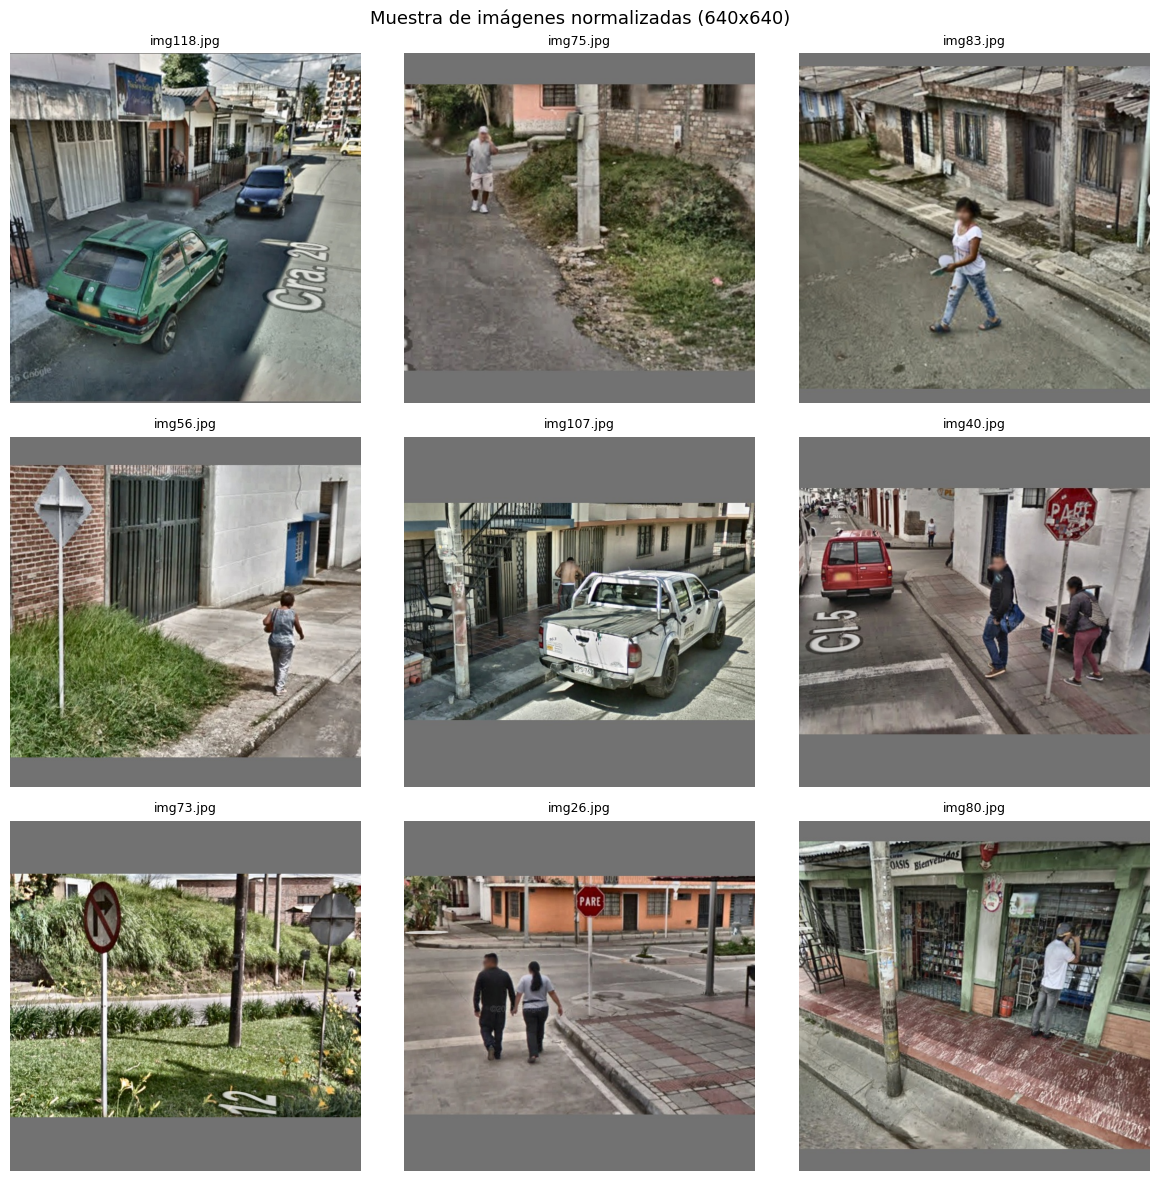

✅ Vista previa guardada en la carpeta de salida.


In [12]:
import matplotlib.pyplot as plt
import random

output_imgs = sorted(output_path.glob(f"*{OUTPUT_FORMAT}"))
sample = random.sample(output_imgs, min(9, len(output_imgs)))

fig, axes = plt.subplots(3, 3, figsize=(12, 12))
axes = axes.flatten()

for ax, img_path in zip(axes, sample):
    img = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img_rgb)
    ax.set_title(img_path.name, fontsize=9)
    ax.axis("off")

# Ocultar ejes sobrantes
for ax in axes[len(sample):]:
    ax.axis("off")

plt.suptitle(f"Muestra de imágenes normalizadas ({TARGET_SIZE}x{TARGET_SIZE})", fontsize=13)
plt.tight_layout()
plt.savefig(output_path / "_preview_cuadricula.jpg", dpi=100)
plt.show()
print("✅ Vista previa guardada en la carpeta de salida.")

## 7. Estadísticas finales

In [13]:
output_imgs = sorted(output_path.glob(f"*{OUTPUT_FORMAT}"))
total_size_mb = sum(f.stat().st_size for f in output_imgs) / (1024 ** 2)

print("="*45)
print("           RESUMEN FINAL")
print("="*45)
print(f"  Imágenes de entrada  : {len(image_files)}")
print(f"  Imágenes de salida   : {len(output_imgs)}")
print(f"  Tamaño               : {TARGET_SIZE}x{TARGET_SIZE} px")
print(f"  Formato              : {OUTPUT_FORMAT}")
print(f"  Tamaño total carpeta : {total_size_mb:.1f} MB")
print(f"  Carpeta de salida    : {output_path.resolve()}")
print("="*45)
print("\n✅ Listo. Ahora puedes importar estas imágenes en Label Studio.")

           RESUMEN FINAL
  Imágenes de entrada  : 120
  Imágenes de salida   : 121
  Tamaño               : 640x640 px
  Formato              : .jpg
  Tamaño total carpeta : 15.0 MB
  Carpeta de salida    : C:\Users\coral\OneDrive\Documentos\pythonproyect\PROYECTO_DETECION_CERCANA\entrenamiento_normalizado

✅ Listo. Ahora puedes importar estas imágenes en Label Studio.
